# U-net

Segmentación semántica

<img src="./misc/u-net-architecture.png" width="75%">

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, utils
from torchvision.io import read_file, decode_jpeg, decode_png, ImageReadMode
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torchvision.io import read_image
import matplotlib.pyplot as plt

In [10]:
# DATASET
import os

# read dataset for u-net
class Dataset(Dataset):
    def __init__(self, data_dir, label_dir):
        self.data_dir = data_dir
        self.label_dir = label_dir
        self.files = [os.path.splitext(f)[0] for f in os.listdir(data_dir)]
        self.transform = T.Resize((512, 512))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        # read image
        image = read_image(os.path.join(self.data_dir, file_name + ".png"), mode=ImageReadMode.RGB)
        
        # read mask
        mask = read_image(os.path.join(self.label_dir, file_name + ".png"), mode=ImageReadMode.GRAY)
        
        # resize
        image = self.transform(image)
        mask = self.transform(mask)
        
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        
        image = image / 255.0
        mask /= 255.0
        mask = torch.round(mask)

        return image, mask
        



ds = Dataset("./data/Synthetic/test", "./data/Synthetic/labels")
ds_loader = DataLoader(ds, batch_size=4)

In [ ]:
import torch
import torch.nn as nn

""" Convolutional block:
    It follows a two 3x3 convolutional layer, each followed by a batch normalization and a relu activation.
"""
class conv_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.relu = nn.ReLU()

    def forward(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        return x

""" Encoder block:
    It consists of an conv_block followed by a max pooling.
    Here the number of filters doubles and the height and width half after every block.
"""
class encoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv = conv_block(in_c, out_c)
        self.pool = nn.MaxPool2d((2, 2))

    def forward(self, inputs):
        x = self.conv(inputs)
        p = self.pool(x)

        return x, p

""" Decoder block:
    The decoder block begins with a transpose convolution, followed by a concatenation with the skip
    connection from the encoder block. Next comes the conv_block.
    Here the number filters decreases by half and the height and width doubles.
"""
class decoder_block(nn.Module):
    def __init__(self, in_c, out_c, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2, padding=0)
        input_dim = out_c + out_c if use_skip else out_c
        self.conv = conv_block(input_dim, out_c)

    def forward(self, inputs, skip):
        x = self.up(inputs)
        if self.use_skip:
            x = torch.cat([x, skip], axis=1)

        x = self.conv(x)

        return x


class build_unet(nn.Module):
    def __init__(self, start_filters=64, use_skip=[True, True, True, True]):
        super().__init__()

        f = start_filters

        """ Encoder """
        self.e1 = encoder_block(3, f)
        self.e2 = encoder_block(f, f*2)
        self.e3 = encoder_block(f*2, f*4)
        self.e4 = encoder_block(f*4, f*8)

        """ Bottleneck """
        self.b = conv_block(f*8, f*16)
        """ Decoder """
        self.d1 = decoder_block(f*16, f*8, use_skip[0])
        self.d2 = decoder_block(f*8, f*4, use_skip[1])
        self.d3 = decoder_block(f*4, f*2, use_skip[2])
        self.d4 = decoder_block(f*2, f, use_skip[3])

        """ Classifier """
        self.outputs = nn.Conv2d(f, 1, kernel_size=1, padding=0)

    def forward(self, inputs):
        """ Encoder """
        s1, p1 = self.e1(inputs)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)
        s4, p4 = self.e4(p3)

        """ Bottleneck """
        b = self.b(p4)

        """ Decoder """
        d1 = self.d1(b, s4)
        d2 = self.d2(d1, s3)
        d3 = self.d3(d2, s2)
        d4 = self.d4(d3, s1)

        """ Classifier """
        outputs = self.outputs(d4)

        return outputs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

inputs = torch.randn((2, 3, 512, 512)).to(device)
model = build_unet().to(device)      
y = model(inputs)
print(y.shape)

torch.Size([2, 1, 512, 512])


# **1. Entrenamiento BASE (Original)**
64 filtros iniciales y todas las Skip Connections activadas

In [12]:
model = build_unet(start_filters=64, use_skip=[True, True, True, True]).to(device)

##  Train model

In [13]:
def train_model(model, num_epochs):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3,
                             weight_decay=1e-5)
    
    for epoch in range(num_epochs):
        for idx, (images, labels) in enumerate(ds_loader):
            # Forward pass
            outputs = model(images.to(device))
            loss = criterion(outputs, labels.to(device))
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print("Lote:", idx)

        print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
train_model(model, num_epochs=200)

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.4136
Lote: 0
Epoch [2/200], Loss: 0.5850
Lote: 0
Epoch [3/200], Loss: 0.3067
Lote: 0
Epoch [4/200], Loss: 0.1611
Lote: 0
Epoch [5/200], Loss: 0.1167
Lote: 0
Epoch [6/200], Loss: 0.0937
Lote: 0
Epoch [7/200], Loss: 0.0756
Lote: 0
Epoch [8/200], Loss: 0.0616
Lote: 0
Epoch [9/200], Loss: 0.0540
Lote: 0
Epoch [10/200], Loss: 0.0512
Lote: 0
Epoch [11/200], Loss: 0.0474
Lote: 0
Epoch [12/200], Loss: 0.0438
Lote: 0
Epoch [13/200], Loss: 0.0416
Lote: 0
Epoch [14/200], Loss: 0.0393
Lote: 0
Epoch [15/200], Loss: 0.0369
Lote: 0
Epoch [16/200], Loss: 0.0331
Lote: 0
Epoch [17/200], Loss: 0.0446
Lote: 0
Epoch [18/200], Loss: 0.0320
Lote: 0
Epoch [19/200], Loss: 0.0394
Lote: 0
Epoch [20/200], Loss: 0.0330
Lote: 0
Epoch [21/200], Loss: 0.0319
Lote: 0
Epoch [22/200], Loss: 0.0293
Lote: 0
Epoch [23/200], Loss: 0.0262
Lote: 0
Epoch [24/200], Loss: 0.0213
Lote: 0
Epoch [25/200], Loss: 0.0201
Lote: 0
Epoch [26/200], Loss: 0.0205
Lote: 0
Epoch [27/200], Loss: 0.0205
Lote: 0
Ep

## Visualize Results

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


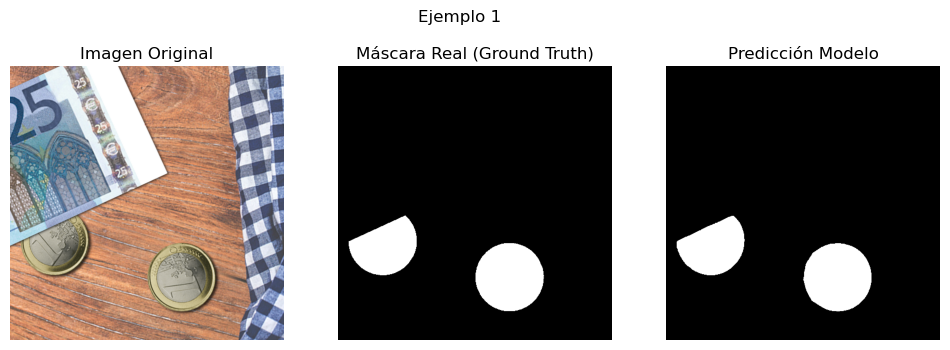

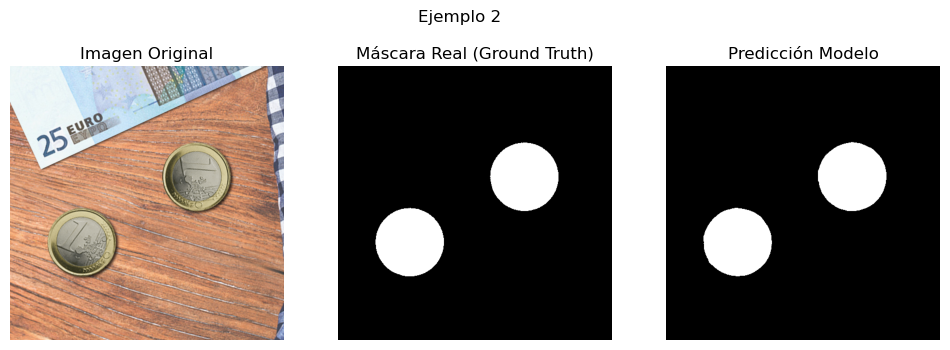

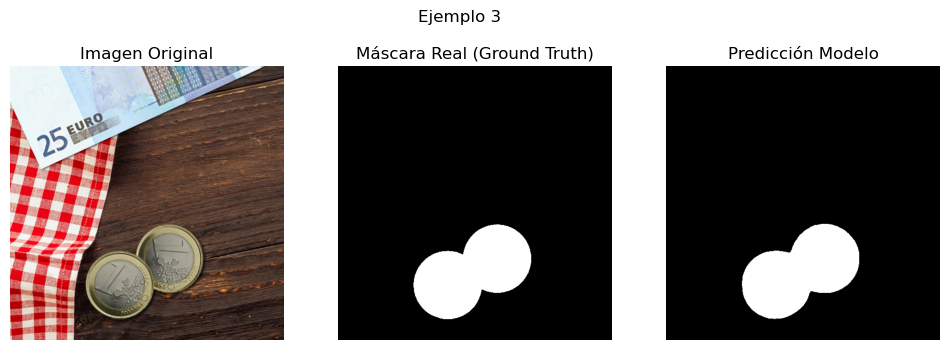

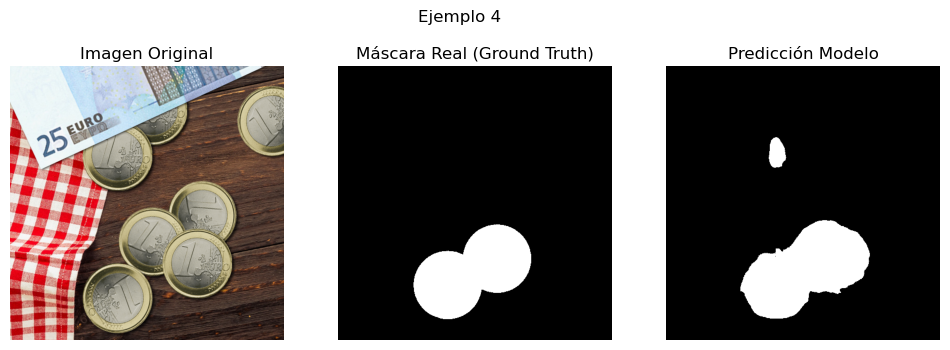

In [14]:
def visualize_prediction(model, dataset_loader, n=4):
    model.eval() # Ponemos el modelo en modo evaluación
    with torch.no_grad():
        images, masks = next(iter(dataset_loader))
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        
        for i in range(n):
            img = images[i].cpu().permute(1, 2, 0).numpy()
            mask = masks[i].cpu().squeeze().numpy()
            pred = outputs[i].cpu().squeeze().numpy()
            
            plt.figure(figsize=(12, 4))
            
            plt.subplot(1, 3, 1)
            plt.title("Imagen Original")
            plt.imshow(img)
            plt.axis('off')
            
            plt.subplot(1, 3, 2)
            plt.title("Máscara Real (Ground Truth)")
            plt.imshow(mask, cmap='gray')
            plt.axis('off')
            
            plt.subplot(1, 3, 3)
            plt.title("Predicción Modelo")
            plt.imshow(pred > 0.5, cmap='gray') 
            plt.axis('off')
            
            plt.suptitle(f'Ejemplo {i+1}')
            plt.show()

visualize_prediction(model, ds_loader)

## Intersección sobre la Unión

In [15]:
def intersection_over_union(model, loader, device):
    model.eval()
    intersection = 0
    union = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            # Convertimos a binario (0 o 1) usando 0.5 como umbral
            preds = (outputs > 0.5).float()
            
            # Calculamos intersección (donde ambos son 1)
            intersection += (preds * labels).sum()
            
            # Calculamos unión (donde alguno es 1)
            union += (preds + labels).clamp(0, 1).sum()
    
    iou = intersection / (union + 1e-6)
    return iou.item()

iou_score = intersection_over_union(model, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Puntuación IoU del modelo actual: 0.9437


# **2. Simplificación**
Progresivamente iremos reduciendo el número de canales con los que trabaja la U-Net

### **32 -> 64 -> 128 -> 256**

In [16]:
model_simplified_1 = build_unet(start_filters=32, use_skip=[True, True, True, True]).to(device)

train_model(model_simplified_1, num_epochs=200)

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.2915
Lote: 0
Epoch [2/200], Loss: 0.1827
Lote: 0
Epoch [3/200], Loss: 0.1222
Lote: 0
Epoch [4/200], Loss: 0.0945
Lote: 0
Epoch [5/200], Loss: 0.0725
Lote: 0
Epoch [6/200], Loss: 0.0600
Lote: 0
Epoch [7/200], Loss: 0.0528
Lote: 0
Epoch [8/200], Loss: 0.0471
Lote: 0
Epoch [9/200], Loss: 0.0418
Lote: 0
Epoch [10/200], Loss: 0.0383
Lote: 0
Epoch [11/200], Loss: 0.0389
Lote: 0
Epoch [12/200], Loss: 0.0470
Lote: 0
Epoch [13/200], Loss: 0.0310
Lote: 0
Epoch [14/200], Loss: 0.0336
Lote: 0
Epoch [15/200], Loss: 0.0283
Lote: 0
Epoch [16/200], Loss: 0.0265
Lote: 0
Epoch [17/200], Loss: 0.0232
Lote: 0
Epoch [18/200], Loss: 0.0218
Lote: 0
Epoch [19/200], Loss: 0.0182
Lote: 0
Epoch [20/200], Loss: 0.0160
Lote: 0
Epoch [21/200], Loss: 0.0144
Lote: 0
Epoch [22/200], Loss: 0.0117
Lote: 0
Epoch [23/200], Loss: 0.0112
Lote: 0
Epoch [24/200], Loss: 0.0100
Lote: 0
Epoch [25/200], Loss: 0.0151
Lote: 0
Epoch [26/200], Loss: 0.0098
Lote: 0
Epoch [27/200], Loss: 0.0191
Lote: 0
Ep

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


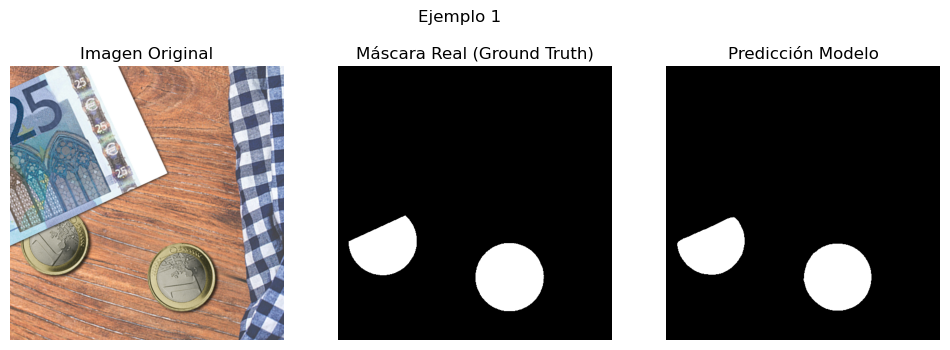

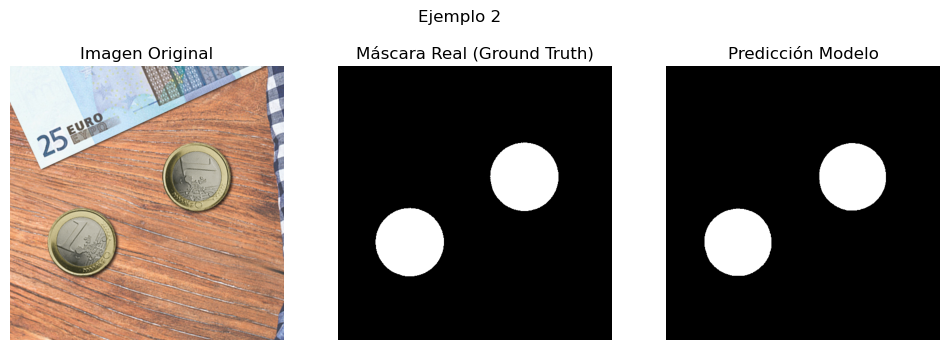

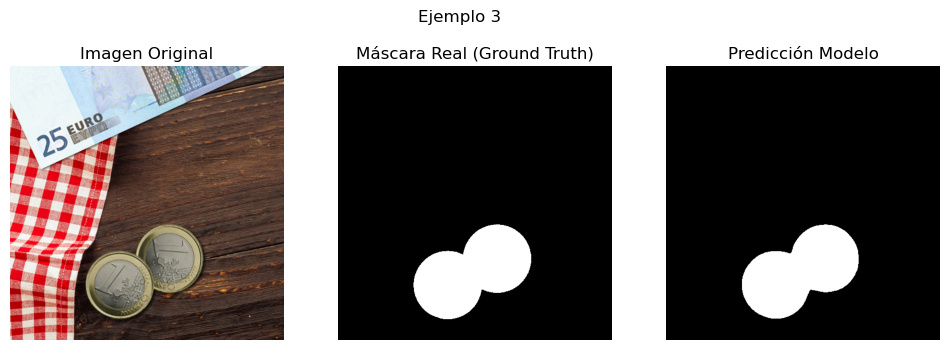

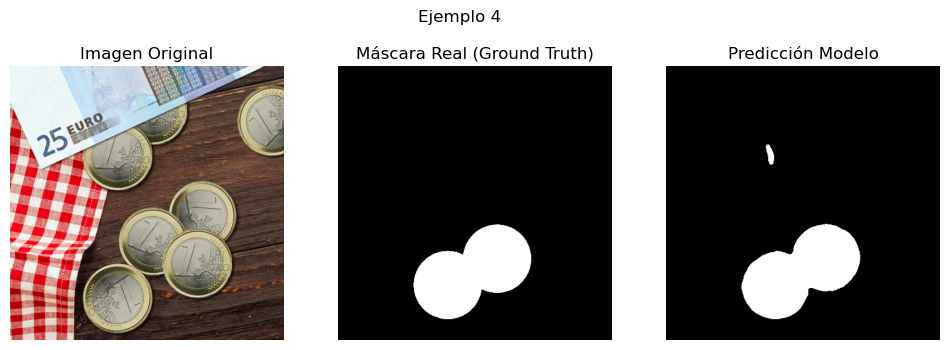

In [17]:
visualize_prediction(model_simplified_1, ds_loader)

In [18]:
iou_score = intersection_over_union(model_simplified_1, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Puntuación IoU del modelo actual: 0.9699


### **16 -> 32 -> 64 -> 128**

In [19]:
model_simplified_2 = build_unet(start_filters=16, use_skip=[True, True, True, True]).to(device)

train_model(model_simplified_2, num_epochs=200)

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.2221
Lote: 0
Epoch [2/200], Loss: 0.1549
Lote: 0
Epoch [3/200], Loss: 0.1262
Lote: 0
Epoch [4/200], Loss: 0.1093
Lote: 0
Epoch [5/200], Loss: 0.0981
Lote: 0
Epoch [6/200], Loss: 0.0896
Lote: 0
Epoch [7/200], Loss: 0.0827
Lote: 0
Epoch [8/200], Loss: 0.0762
Lote: 0
Epoch [9/200], Loss: 0.0699
Lote: 0
Epoch [10/200], Loss: 0.0636
Lote: 0
Epoch [11/200], Loss: 0.0575
Lote: 0
Epoch [12/200], Loss: 0.0508
Lote: 0
Epoch [13/200], Loss: 0.0451
Lote: 0
Epoch [14/200], Loss: 0.0413
Lote: 0
Epoch [15/200], Loss: 0.0324
Lote: 0
Epoch [16/200], Loss: 0.0412
Lote: 0
Epoch [17/200], Loss: 0.0319
Lote: 0
Epoch [18/200], Loss: 0.0312
Lote: 0
Epoch [19/200], Loss: 0.0268
Lote: 0
Epoch [20/200], Loss: 0.0230
Lote: 0
Epoch [21/200], Loss: 0.0202
Lote: 0
Epoch [22/200], Loss: 0.0199
Lote: 0
Epoch [23/200], Loss: 0.0146
Lote: 0
Epoch [24/200], Loss: 0.0161
Lote: 0
Epoch [25/200], Loss: 0.0130
Lote: 0
Epoch [26/200], Loss: 0.0111
Lote: 0
Epoch [27/200], Loss: 0.0093
Lote: 0
Ep

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


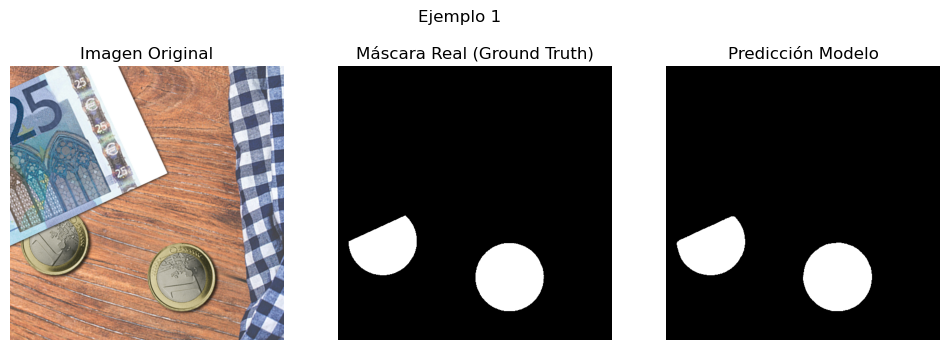

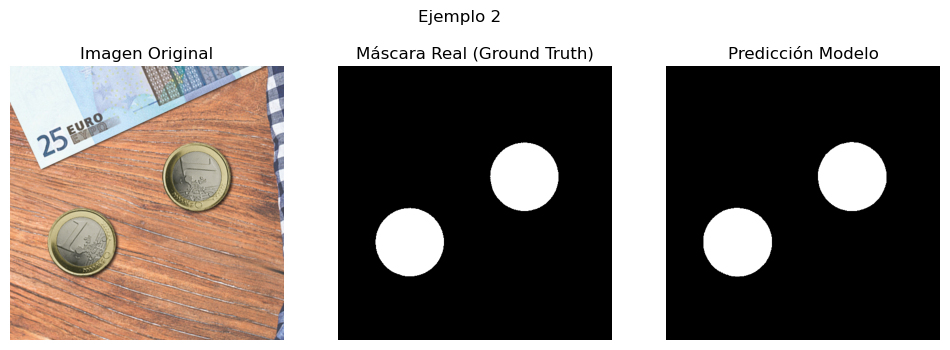

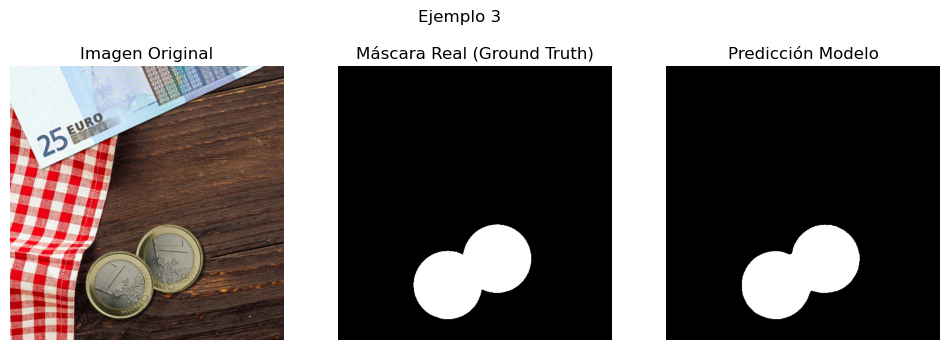

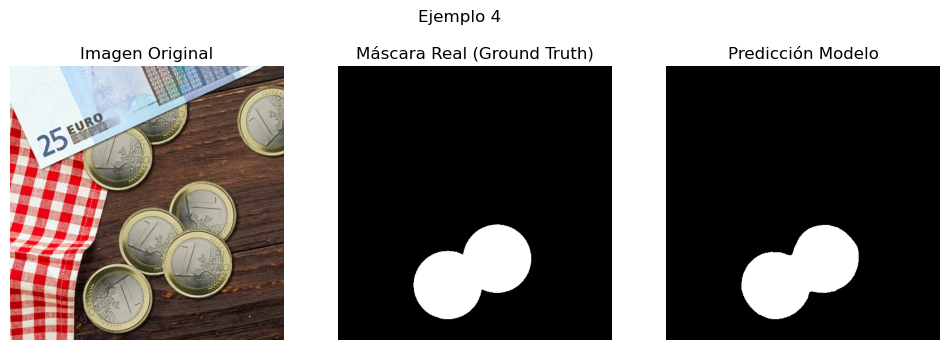

In [20]:
visualize_prediction(model_simplified_2, ds_loader)

In [21]:
iou_score = intersection_over_union(model_simplified_2, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Puntuación IoU del modelo actual: 0.9852


### **8 -> 16 -> 32 -> 64**

In [22]:
model_simplified_3 = build_unet(start_filters=8, use_skip=[True, True, True, True]).to(device)
train_model(model_simplified_3, num_epochs=200)

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.4031
Lote: 0
Epoch [2/200], Loss: 0.3478
Lote: 0
Epoch [3/200], Loss: 0.3060
Lote: 0
Epoch [4/200], Loss: 0.2688
Lote: 0
Epoch [5/200], Loss: 0.2377
Lote: 0
Epoch [6/200], Loss: 0.2072
Lote: 0
Epoch [7/200], Loss: 0.1894
Lote: 0
Epoch [8/200], Loss: 0.1615
Lote: 0
Epoch [9/200], Loss: 0.1465
Lote: 0
Epoch [10/200], Loss: 0.1313
Lote: 0
Epoch [11/200], Loss: 0.1159
Lote: 0
Epoch [12/200], Loss: 0.1028
Lote: 0
Epoch [13/200], Loss: 0.0895
Lote: 0
Epoch [14/200], Loss: 0.0790
Lote: 0
Epoch [15/200], Loss: 0.0711
Lote: 0
Epoch [16/200], Loss: 0.0647
Lote: 0
Epoch [17/200], Loss: 0.0582
Lote: 0
Epoch [18/200], Loss: 0.0527
Lote: 0
Epoch [19/200], Loss: 0.0479
Lote: 0
Epoch [20/200], Loss: 0.0431
Lote: 0
Epoch [21/200], Loss: 0.0396
Lote: 0
Epoch [22/200], Loss: 0.0356
Lote: 0
Epoch [23/200], Loss: 0.0328
Lote: 0
Epoch [24/200], Loss: 0.0301
Lote: 0
Epoch [25/200], Loss: 0.0281
Lote: 0
Epoch [26/200], Loss: 0.0259
Lote: 0
Epoch [27/200], Loss: 0.0240
Lote: 0
Ep

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


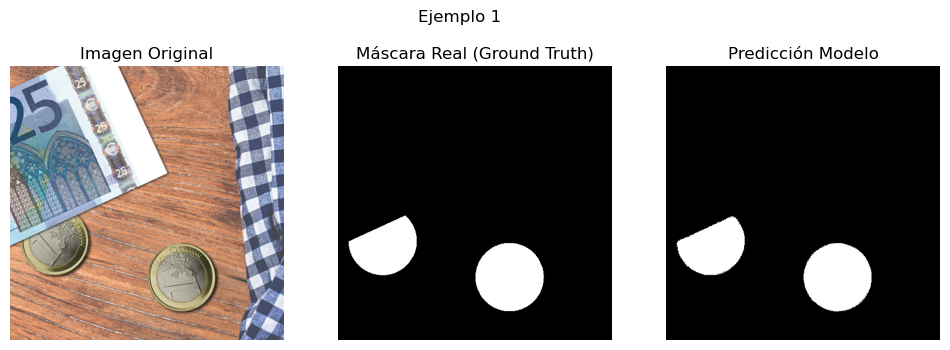

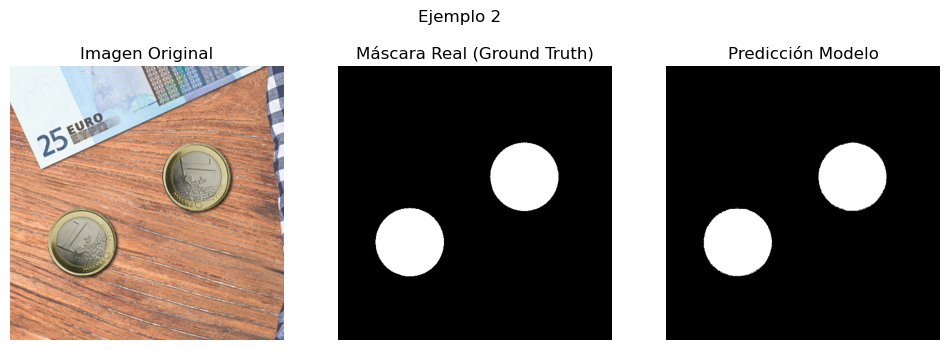

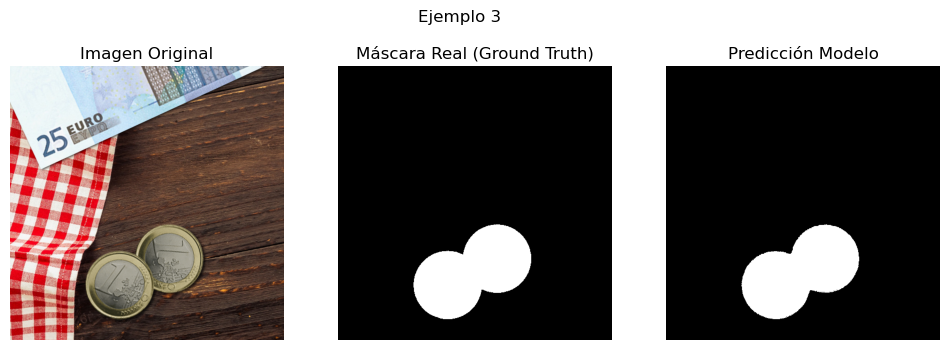

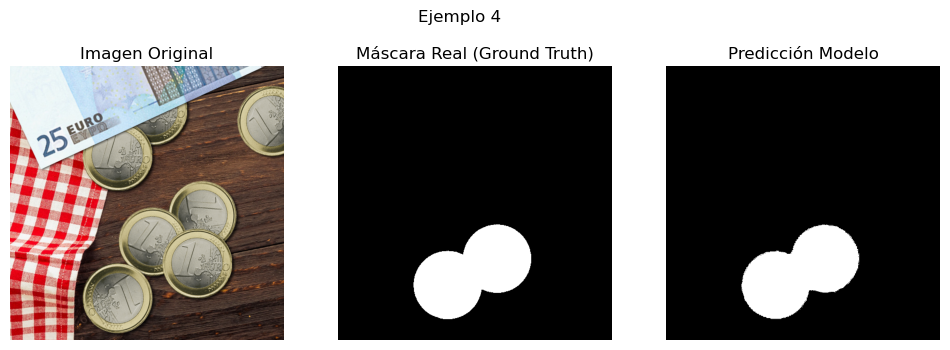

In [23]:
visualize_prediction(model_simplified_3, ds_loader)

In [24]:
iou_score = intersection_over_union(model_simplified_3, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Puntuación IoU del modelo actual: 0.9866


# **2. Ablación**
Progresivamente iremos reduciendo el los skips que se hacen en U-Net

### **Quitar 1º skip**

In [25]:
model_ablated_1 = build_unet(start_filters=64, use_skip=[False, True, True, True]).to(device)
train_model(model_ablated_1, num_epochs=200)

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.2753
Lote: 0
Epoch [2/200], Loss: 0.4869
Lote: 0
Epoch [3/200], Loss: 0.2283
Lote: 0
Epoch [4/200], Loss: 0.1091
Lote: 0
Epoch [5/200], Loss: 0.0967
Lote: 0
Epoch [6/200], Loss: 0.0680
Lote: 0
Epoch [7/200], Loss: 0.0617
Lote: 0
Epoch [8/200], Loss: 0.0534
Lote: 0
Epoch [9/200], Loss: 0.0497
Lote: 0
Epoch [10/200], Loss: 0.0483
Lote: 0
Epoch [11/200], Loss: 0.0465
Lote: 0
Epoch [12/200], Loss: 0.0427
Lote: 0
Epoch [13/200], Loss: 0.0411
Lote: 0
Epoch [14/200], Loss: 0.0392
Lote: 0
Epoch [15/200], Loss: 0.0430
Lote: 0
Epoch [16/200], Loss: 0.0381
Lote: 0
Epoch [17/200], Loss: 0.0340
Lote: 0
Epoch [18/200], Loss: 0.0337
Lote: 0
Epoch [19/200], Loss: 0.0359
Lote: 0
Epoch [20/200], Loss: 0.0360
Lote: 0
Epoch [21/200], Loss: 0.0359
Lote: 0
Epoch [22/200], Loss: 0.0345
Lote: 0
Epoch [23/200], Loss: 0.0337
Lote: 0
Epoch [24/200], Loss: 0.0325
Lote: 0
Epoch [25/200], Loss: 0.0312
Lote: 0
Epoch [26/200], Loss: 0.0298
Lote: 0
Epoch [27/200], Loss: 0.0283
Lote: 0
Ep

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


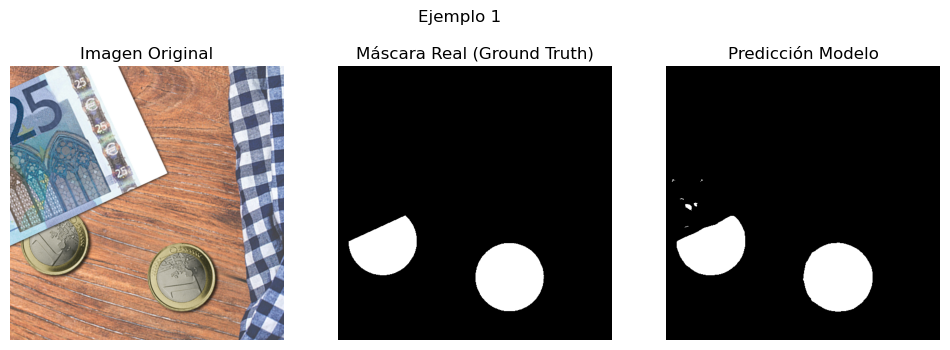

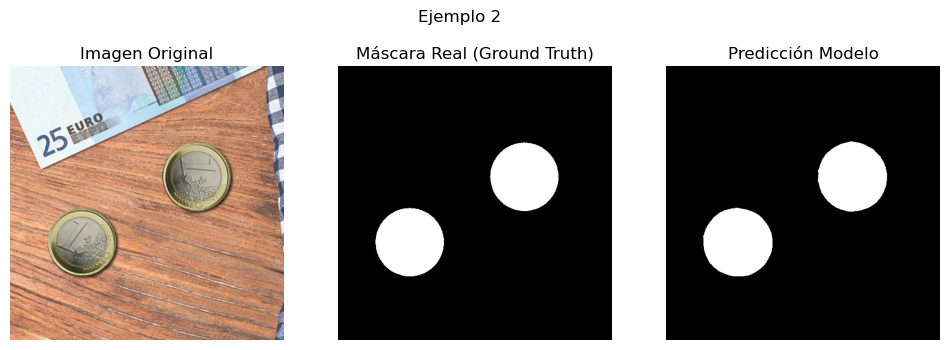

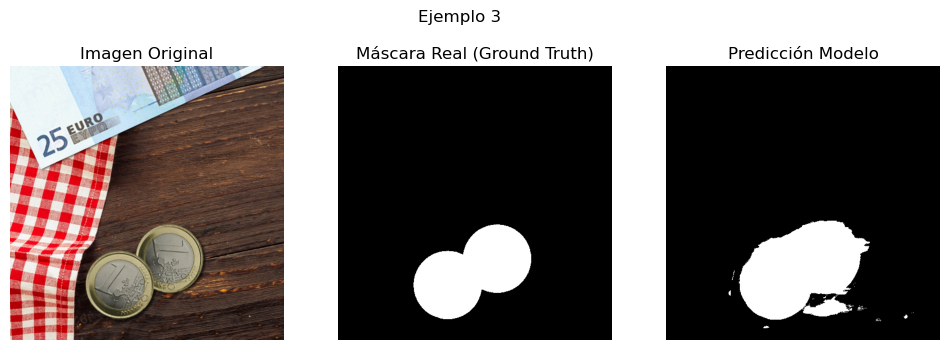

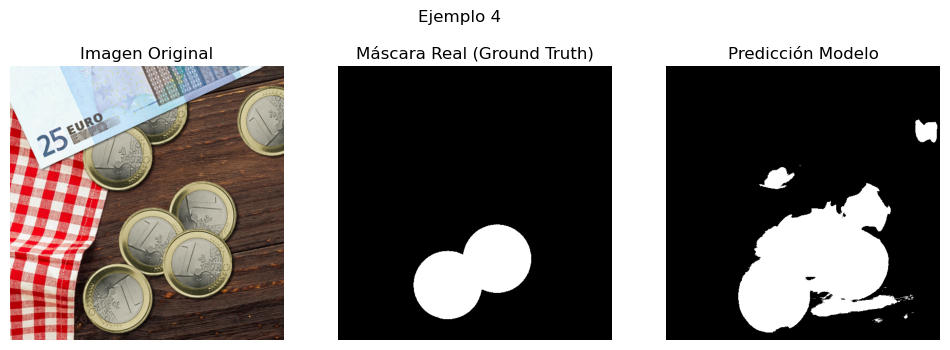

In [26]:
visualize_prediction(model_ablated_1, ds_loader)

In [27]:
iou_score = intersection_over_union(model_ablated_1, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Puntuación IoU del modelo actual: 0.7181


### **Quitar 1º y 2º skips**

In [28]:
model_ablated_2 = build_unet(start_filters=64, use_skip=[False, False, True, True]).to(device)
train_model(model_ablated_2, num_epochs=200)

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.2153
Lote: 0
Epoch [2/200], Loss: 0.5817
Lote: 0
Epoch [3/200], Loss: 0.1492
Lote: 0
Epoch [4/200], Loss: 0.1053
Lote: 0
Epoch [5/200], Loss: 0.0751
Lote: 0
Epoch [6/200], Loss: 0.0689
Lote: 0
Epoch [7/200], Loss: 0.0533
Lote: 0
Epoch [8/200], Loss: 0.0469
Lote: 0
Epoch [9/200], Loss: 0.0534
Lote: 0
Epoch [10/200], Loss: 0.0434
Lote: 0
Epoch [11/200], Loss: 0.0435
Lote: 0
Epoch [12/200], Loss: 0.0411
Lote: 0
Epoch [13/200], Loss: 0.0395
Lote: 0
Epoch [14/200], Loss: 0.0383
Lote: 0
Epoch [15/200], Loss: 0.0340
Lote: 0
Epoch [16/200], Loss: 0.0319
Lote: 0
Epoch [17/200], Loss: 0.0308
Lote: 0
Epoch [18/200], Loss: 0.0285
Lote: 0
Epoch [19/200], Loss: 0.0267
Lote: 0
Epoch [20/200], Loss: 0.0262
Lote: 0
Epoch [21/200], Loss: 0.0251
Lote: 0
Epoch [22/200], Loss: 0.0240
Lote: 0
Epoch [23/200], Loss: 0.0233
Lote: 0
Epoch [24/200], Loss: 0.0219
Lote: 0
Epoch [25/200], Loss: 0.0209
Lote: 0
Epoch [26/200], Loss: 0.0197
Lote: 0
Epoch [27/200], Loss: 0.0178
Lote: 0
Ep

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


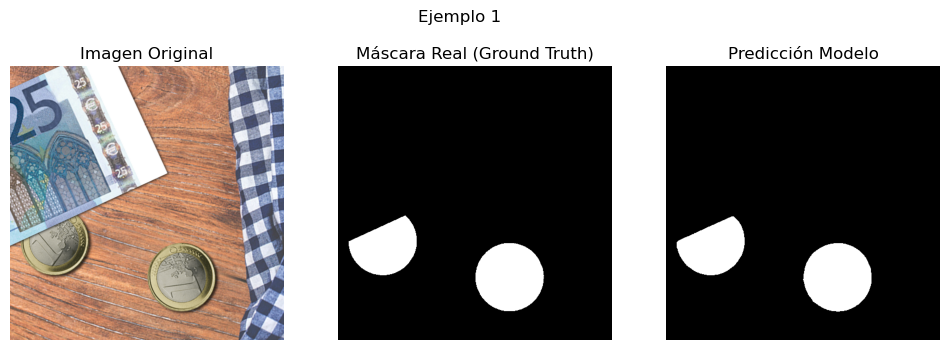

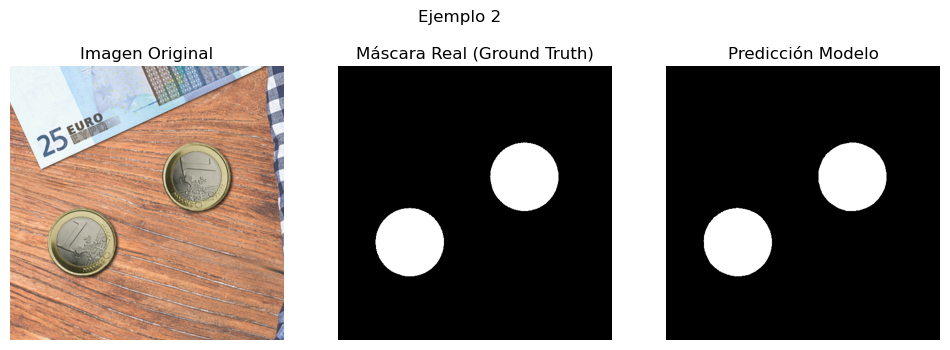

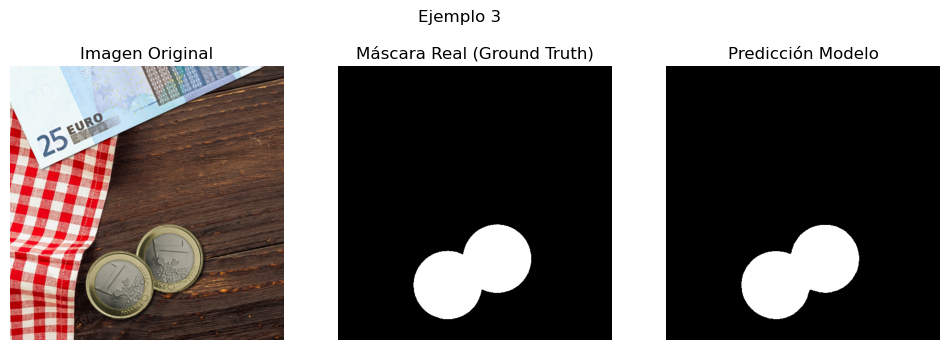

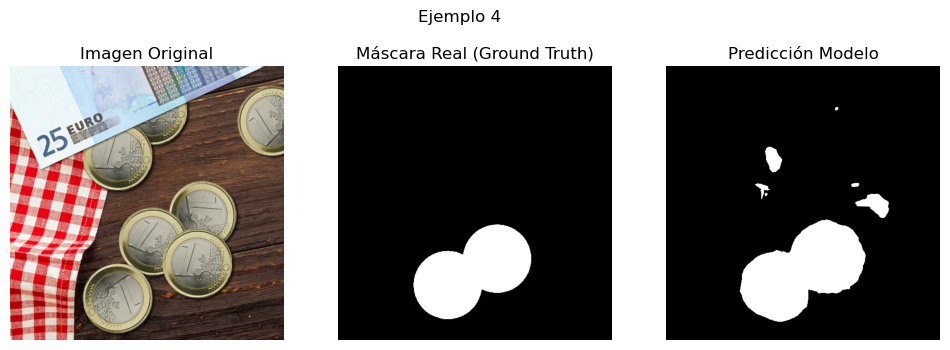

In [29]:
visualize_prediction(model_ablated_2, ds_loader)

In [30]:
iou_score = intersection_over_union(model_ablated_2, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Puntuación IoU del modelo actual: 0.9389


### **Quitar 1º, 2º y 3º skips**

In [31]:
model_ablated_3 = build_unet(start_filters=64, use_skip=[False, False, False, True]).to(device)
train_model(model_ablated_3, num_epochs=200)

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.1881
Lote: 0
Epoch [2/200], Loss: 0.9285
Lote: 0
Epoch [3/200], Loss: 0.1857
Lote: 0
Epoch [4/200], Loss: 0.1194
Lote: 0
Epoch [5/200], Loss: 0.0833
Lote: 0
Epoch [6/200], Loss: 0.0706
Lote: 0
Epoch [7/200], Loss: 0.0656
Lote: 0
Epoch [8/200], Loss: 0.0561
Lote: 0
Epoch [9/200], Loss: 0.0544
Lote: 0
Epoch [10/200], Loss: 0.0551
Lote: 0
Epoch [11/200], Loss: 0.0517
Lote: 0
Epoch [12/200], Loss: 0.0478
Lote: 0
Epoch [13/200], Loss: 0.0471
Lote: 0
Epoch [14/200], Loss: 0.0461
Lote: 0
Epoch [15/200], Loss: 0.0444
Lote: 0
Epoch [16/200], Loss: 0.0428
Lote: 0
Epoch [17/200], Loss: 0.0421
Lote: 0
Epoch [18/200], Loss: 0.0415
Lote: 0
Epoch [19/200], Loss: 0.0409
Lote: 0
Epoch [20/200], Loss: 0.0389
Lote: 0
Epoch [21/200], Loss: 0.0379
Lote: 0
Epoch [22/200], Loss: 0.0375
Lote: 0
Epoch [23/200], Loss: 0.0362
Lote: 0
Epoch [24/200], Loss: 0.0352
Lote: 0
Epoch [25/200], Loss: 0.0338
Lote: 0
Epoch [26/200], Loss: 0.0332
Lote: 0
Epoch [27/200], Loss: 0.0323
Lote: 0
Ep

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


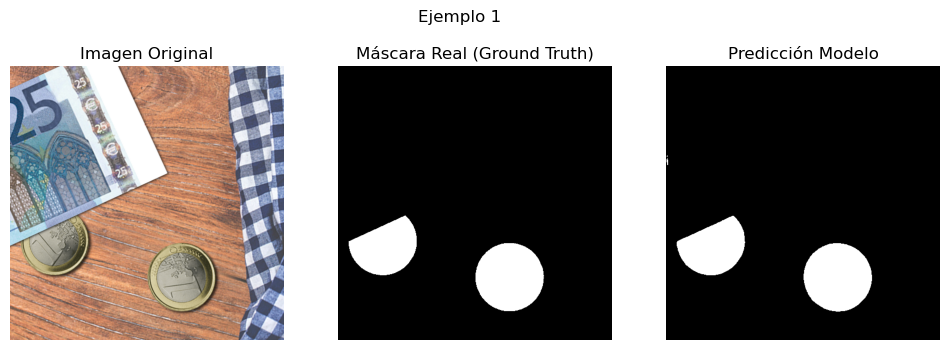

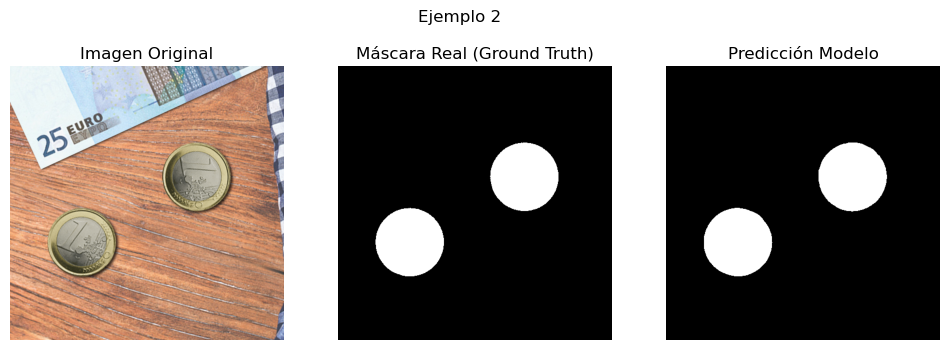

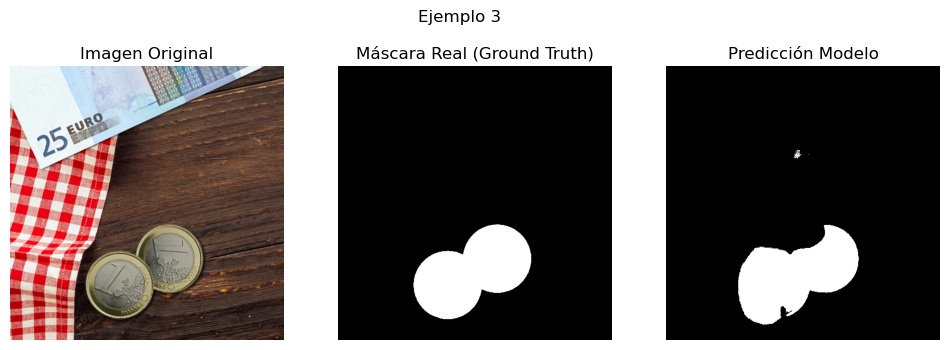

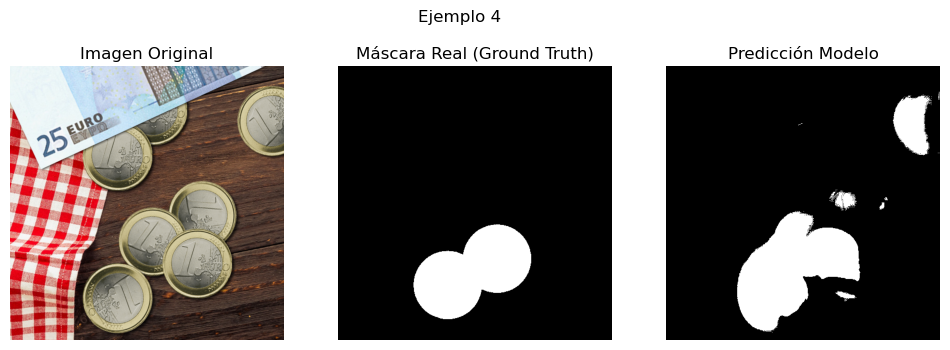

In [32]:
visualize_prediction(model_ablated_3, ds_loader)

In [35]:
iou_score = intersection_over_union(model_ablated_3, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_10080\1366429509.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Puntuación IoU del modelo actual: 0.8086


### **Quitar todos los skips**

No lo hacemos por cuestión de consumo de recursos y tiempo de ejecución.

In [ ]:
model_ablated_4 = build_unet(start_filters=64, use_skip=[False, False, False, False]).to(device)
train_model(model_ablated_4, num_epochs=200)

In [ ]:
visualize_prediction(model_ablated_4, ds_loader)

In [ ]:
iou_score = intersection_over_union(model_ablated_4, ds_loader, device)
print(f"Puntuación IoU del modelo actual: {iou_score:.4f}")

# Estudio de segmentación semántica mediante U-Net

## 1. Objetivo del trabajo

El objetivo de este trabajo es implementar una red **U-Net** para la segmentación semántica de monedas en imágenes sintéticas y analizar el efecto de dos aspectos clave de la arquitectura:

- **Simplificación del modelo**, reduciendo progresivamente el número de filtros.
- **Ablación de las skip connections**, eliminándolas de forma progresiva para estudiar su aportación.

El análisis se basa tanto en métricas cuantitativas como en la inspección visual de los resultados obtenidos.

---

## 2. Descripción del modelo

La arquitectura utilizada corresponde a una **U-Net clásica**, compuesta por:

- Un **encoder** con bloques convolucionales seguidos de max-pooling, donde se reduce la resolución espacial y se incrementa el número de canales.
- Un **bottleneck** que captura la representación más abstracta de la imagen.
- Un **decoder** que recupera la resolución original mediante convoluciones transpuestas.
- **Skip connections** que conectan encoder y decoder en cada nivel, permitiendo reutilizar información espacial de alta resolución.

La salida del modelo es un mapa de segmentación binaria que indica, a nivel de píxel, si pertenece o no a la clase “moneda”.

---

## 3. Dataset y consideraciones importantes

El dataset utilizado presenta varias particularidades que condicionan la interpretación de los resultados:

- El entrenamiento y la evaluación se realizan sobre el **mismo conjunto de datos**, debido al tamaño reducido del dataset.
- El conjunto utilizado es extremadamente pequeño (4 imágenes).
- Se ha detectado que la etiqueta correspondiente a `money_008.png` está **duplicada** y no corresponde a la imagen real, lo que introduce **ruido en las etiquetas**.
- Existe una carpeta adicional (`images/`) que no se utiliza durante el entrenamiento, lo que sugiere una posible división original de train/test que no se ha aplicado en esta práctica.

Estas limitaciones implican que los resultados **no deben interpretarse como capacidad de generalización**, sino como una comparación relativa entre distintas configuraciones del modelo bajo las mismas condiciones.

---

## 4. Métrica de evaluación: Intersection over Union (IoU)

Para evaluar la calidad de la segmentación se emplea la métrica **Intersection over Union (IoU)**, definida como:

***IoU = Intersección/Unión***

donde:
- la intersección representa los píxeles correctamente clasificados como moneda,
- la unión representa los píxeles clasificados como moneda por la predicción o por la etiqueta.

En este trabajo se calcula un **IoU global**, acumulando intersección y unión a lo largo de todo el dataset. Un valor cercano a 1 indica un alto solapamiento entre la predicción del modelo y la etiqueta.

---

## 5. Estudio de simplificación del modelo

Se entrenaron varias versiones del modelo manteniendo todas las skip connections activas y reduciendo progresivamente el número de filtros iniciales:

| Modelo | Filtros iniciales | IoU |
|------|------------------|-----|
| Base | 64 | 0.9437 |
| Simplificación 1 | 32 | 0.9699 |
| Simplificación 2 | 16 | 0.9852 |
| Simplificación 3 | 8  | 0.9866 |

### Análisis

De forma llamativa, los modelos simplificados obtienen valores de IoU superiores al modelo base. Este comportamiento puede explicarse por:

- El **tamaño reducido del dataset**, que favorece el sobreajuste en modelos con mayor capacidad.
- La reducción de filtros actúa como una **regularización implícita**, forzando al modelo a aprender representaciones más simples.
- La tarea de segmentación es relativamente sencilla (monedas con formas bien definidas), por lo que no requiere una gran capacidad expresiva.

Visualmente, los modelos simplificados producen segmentaciones limpias y coherentes en la mayoría de los ejemplos.

---

## 6. Estudio de ablación de skip connections

Se realizó una ablación progresiva eliminando skip connections desde los niveles más profundos hasta los más superficiales:

| Modelo | Skip connections activas | IoU |
|------|--------------------------|-----|
| Ablación 1 | [False, True, True, True] | 0.7181 |
| Ablación 2 | [False, False, True, True] | 0.9389 |
| Ablación 3 | [False, False, False, True] | 0.8086 |

### Análisis

Los resultados muestran que:

- La eliminación del primer skip connection provoca una caída notable del IoU, indicando la importancia de las conexiones profundas para la reconstrucción global.
- La degradación no es estrictamente monotónica, lo cual es esperable dado:
  - el tamaño reducido del dataset,
  - la alta variabilidad del entrenamiento,
  - la presencia de etiquetas incorrectas.
- En particular, el ejemplo con múltiples monedas (imagen 8) se ve afectado por una etiqueta errónea, lo que penaliza métricamente a los modelos que producen segmentaciones visualmente más coherentes con la imagen real.

Se observa que el modelo con solo el último skip activo produce una segmentación visualmente más cercana a la imagen original en el caso problemático, aunque esto no se refleje necesariamente en una mejora del IoU.

---

## 7. Comparación con el modelo base del profesor

El modelo proporcionado por el profesor no utiliza skip connections y se comporta esencialmente como un **autoencoder convolucional**. Teóricamente, la ablación total de skip connections en la U-Net tiende a un comportamiento similar.

Debido al coste computacional y al tiempo disponible, la ablación completa no se ejecutó. No obstante, los resultados observados en la ablación progresiva permiten inferir razonablemente que el comportamiento final sería comparable al del modelo base proporcionado.

---

## 8. Limitaciones del estudio

Las principales limitaciones de este trabajo son:

- Dataset extremadamente pequeño.
- Evaluación realizada sobre el mismo conjunto usado para el entrenamiento.
- Presencia de una etiqueta incorrecta que afecta tanto a las métricas como a la interpretación visual.

---

## 9. Conclusiones

- Las skip connections mejoran la capacidad del modelo para ajustarse a las etiquetas, pero también facilitan el sobreajuste cuando el dataset es pequeño o contiene errores.
- La simplificación del modelo puede mejorar el rendimiento en escenarios con pocos datos.
- La ablación progresiva permite entender mejor qué componentes de la arquitectura contribuyen a la calidad de la segmentación.
- Los resultados obtenidos son coherentes con el funcionamiento teórico de U-Net y con las limitaciones prácticas del dataset empleado.
